# **Step 1:** Importing Libraries and Connecting to Google Drive

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from google.colab import drive

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 2:** Reading Images and the Annotations File

In [4]:
# Annotations for previous training:

data_path = '/content/drive/MyDrive/FinalProject/Images1'
# For running in Tamir's env: '/content/drive/MyDrive/Colab Notebooks/Intro ML & DL/suvelocity/Project Semi Supervised'
# For running in Nitzan's env:'/content/drive/MyDrive/FinalProject/Images1'
# Load the annotations file (x, y, angle)
annotations = np.load(os.path.join(data_path, 'agent_0_annotations.npy'))

# === ORIGINAL NORMALIZATION VALUES ===
max_x = 180.0
max_y = 180.0
max_angle = 360.0

# Normalize all annotations to [0, 1]
annotations = annotations / np.array([max_x, max_y, max_angle])

# Collect image file names
image_files = [f for f in os.listdir(data_path) if f.lower().endswith('.jpg')]

# Optional: Print image size to confirm (using first image)
img_sample = Image.open(os.path.join(data_path, image_files[0]))
print("Sample image size:", img_sample.size)  # (width, height)

Sample image size: (360, 360)


# **Step 3:** Custom Dataset Class

In [5]:
# Define a custom dataset class by inheriting from PyTorch's Dataset base class
class ImageDataset4Autoencoder(Dataset):
    def __init__(self, image_dir, image_files, annotations, transform=None): # Initialize the dataset with image directory, file list, annotations, and optional transforms
        self.image_dir = image_dir
        self.image_files = image_files
        self.annotations = annotations
        self.transform = transform

    def __len__(self): # Define how many items the dataset contains
        return len(self.image_files)

    def __getitem__(self, idx): # Get a single image and its corresponding annotation by index
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path) #.convert("RGB") # Ensure image is in RGB format

        if self.transform:
            image = self.transform(image)

        # For Autoencoder, the target is the image itself
        return image, image

# **Step 4:** Image Transformation and Augmentation


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# **Step 5:** Splitting into Train/Test and Preparing the DataLoader\

In [7]:
# Split the image filenames and annotations into training and testing sets (80% train, 20% test)
train_files, test_files, train_annots, test_annots = train_test_split(
    image_files, annotations, test_size=0.2, random_state=42
)
# random_state sets a fixed seed for random number generation, ensuring that the data split is the same every time you run the code
# Without random_split the split will change every time — making it impossible to reproduce or consistently compare results

train_dataset = ImageDataset4Autoencoder(data_path, train_files, train_annots, transform=transform)
test_dataset = ImageDataset4Autoencoder(data_path, test_files, test_annots, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
image, annotation = train_dataset.__getitem__(0)
print(image.shape)
print(annotation.shape)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


# **Step 6:** Define the Autoencoder model class

In [10]:

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # 16x112x112
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 32x56x56
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 64x28x28
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 128x14x14
            nn.ReLU(True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# 256x7x7
            nn.ReLU(True)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), # 128x14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),   # 64x28x28
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),    # 32x56x56
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),    # 16x112x112
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),     # 3x224x224
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# **Step 7:** Instantiate the model and move it to the device (GPU/CPU)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
net_autoencoder = Autoencoder()
net_autoencoder.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU(inplace=True)
    (6):

# **Step 8:** Training Setup for Autoencoder

In [14]:
# Define the loss function and optimizer for the Autoencoder
criterion_autoencoder = nn.MSELoss()
optimizer_autoencoder = optim.Adam(net_autoencoder.parameters(), lr=0.001) # You can adjust the learning rate

num_epochs_autoencoder = 20 # You can adjust the number of epochs
loss_list_autoencoder = []

# **Step 9:** Training the Autoencoder

In [15]:
# Training loop for Autoencoder
for epoch in range(num_epochs_autoencoder): # 20 epochs
    net_autoencoder.train()
    running_loss = 0.0
    for inputs, _ in train_loader: # Autoencoder uses the image as both input and target
        inputs = inputs.to(device)

        optimizer_autoencoder.zero_grad()
        outputs = net_autoencoder(inputs)
        loss = criterion_autoencoder(outputs, inputs) # Compare output with input
        loss.backward()
        optimizer_autoencoder.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    loss_list_autoencoder.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs_autoencoder}], Loss: {epoch_loss:.4f}")

print("Autoencoder training finished")

Epoch [1/20], Loss: 0.0765
Epoch [2/20], Loss: 0.0352
Epoch [3/20], Loss: 0.0168
Epoch [4/20], Loss: 0.0126
Epoch [5/20], Loss: 0.0113
Epoch [6/20], Loss: 0.0105
Epoch [7/20], Loss: 0.0101
Epoch [8/20], Loss: 0.0097
Epoch [9/20], Loss: 0.0093
Epoch [10/20], Loss: 0.0082
Epoch [11/20], Loss: 0.0054
Epoch [12/20], Loss: 0.0041
Epoch [13/20], Loss: 0.0037
Epoch [14/20], Loss: 0.0036
Epoch [15/20], Loss: 0.0034
Epoch [16/20], Loss: 0.0033
Epoch [17/20], Loss: 0.0034
Epoch [18/20], Loss: 0.0032
Epoch [19/20], Loss: 0.0031
Epoch [20/20], Loss: 0.0030
Autoencoder training finished


# **Step 10:** Graph

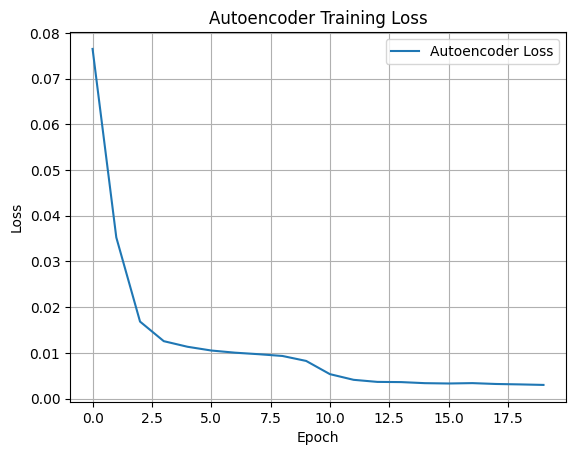

In [16]:
plt.plot(loss_list_autoencoder, label='Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()


# **Step 11:** Comparsion between an original image and its reconstruction by the Autoencoder

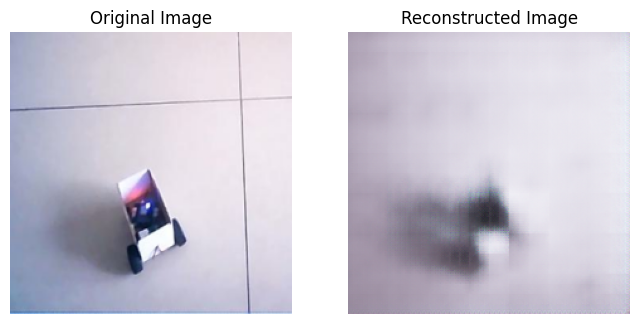

In [17]:
net_autoencoder.eval()

sample_input, _ = next(iter(train_loader))
sample_input = sample_input.to(device)

with torch.no_grad():
    reconstructed = net_autoencoder(sample_input)

original = sample_input.cpu().detach()
reconstructed = reconstructed.cpu().detach()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original[0].permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(reconstructed[0].permute(1, 2, 0))
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

plt.show()
